## Exercise II: Profiling Diffusion Process Code

In [1]:
import cProfile

### Task 2.1 Profile the diffusion code with cProfile and line_profiler the computation

In [2]:
grid_shape = (640, 640)


def evolve(grid, dt, D=1.0):
    xmax, ymax = grid_shape
    new_grid = [[0.0] * ymax for x in range(xmax)]
    for i in range(xmax):
        for j in range(ymax):
            grid_xx = (
                grid[(i + 1) % xmax][j] + grid[(i - 1) % xmax][j] - 2.0 * grid[i][j]
            )
            grid_yy = (
                grid[i][(j + 1) % ymax] + grid[i][(j - 1) % ymax] - 2.0 * grid[i][j]
            )
            new_grid[i][j] = grid[i][j] + D * (grid_xx + grid_yy) * dt
    return new_grid


def run_experiment(num_iterations):
    # Setting up initial conditions 
    xmax, ymax = grid_shape
    grid = [[0.0] * ymax for x in range(xmax)]

    # These initial conditions are simulating a drop of dye in the middle of our
    # simulated region
    block_low = int(grid_shape[0] * 0.4)
    block_high = int(grid_shape[0] * 0.5)
    for i in range(block_low, block_high):
        for j in range(block_low, block_high):
            grid[i][j] = 0.005

    # Evolve the initial conditions
    for i in range(num_iterations):
        grid = evolve(grid, 0.1)

#### Profiling with cProfile

In [3]:
cProfile.run('run_experiment(10)', 'profile.stats')

In [4]:
!snakeviz profile.stats

snakeviz web server started on 127.0.0.1:8080; enter Ctrl-C to exit
http://127.0.0.1:8080/snakeviz/%2FUsers%2Fakira%2FHPC-Intro%2FAssignment1%2Fprofile.stats
^C


#### Task 2.1 Profile the diffusion code with cProfile and line_profiler the computation

After using cProfile, we see that the majority of time is spent in the evolve function. We use line_profiler to further investigate and add the '@profile' decorator to the function as seen in the screeenshot below.

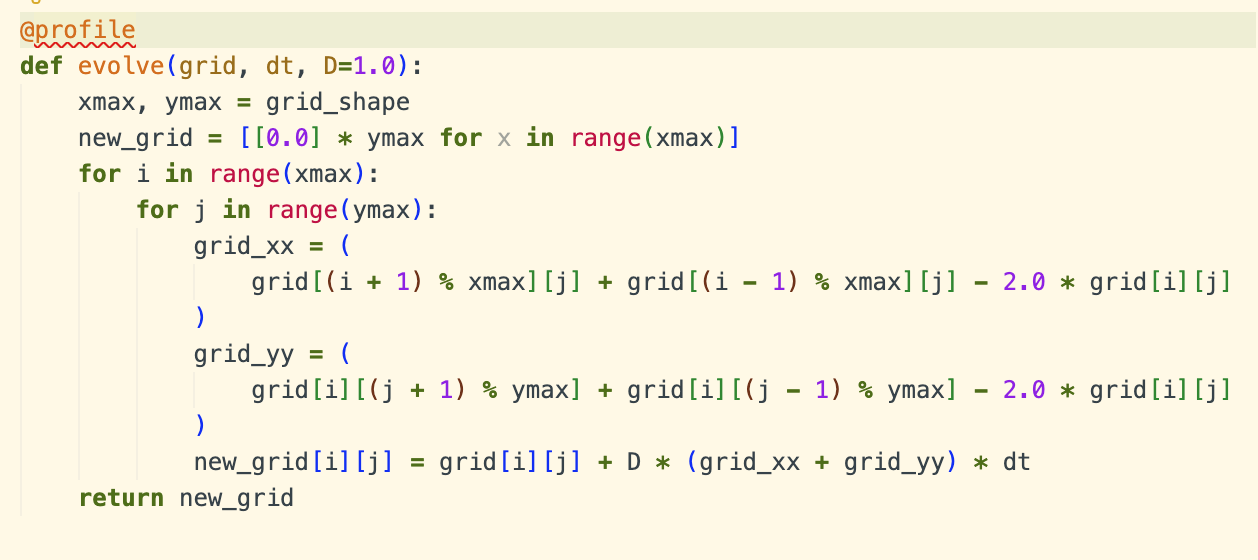

In [5]:
!python -m kernprof -l diffusion.py --num-iterations 10


Wrote profile results to 'diffusion.py.lprof'
Inspect results with:
python -m line_profiler -rmt diffusion.py.lprof


We can then investigate the profilling results below

In [6]:
!python -m line_profiler diffusion.py.lprof

Timer unit: 1e-06 s

Total time: 10.0516 s
File: diffusion.py
Function: evolve at line 5

Line #      Hits         Time  Per Hit   % Time  Line Contents
     5                                           @profile
     6                                           def evolve(grid, dt, D=1.0):
     7        10         13.0      1.3      0.0      xmax, ymax = grid_shape
     8        10       6712.0    671.2      0.1      new_grid = [[0.0] * ymax for x in range(xmax)]
     9      6410       1838.0      0.3      0.0      for i in range(xmax):
    10   4102400    1062705.0      0.3     10.6          for j in range(ymax):
    11   4096000     962715.0      0.2      9.6              grid_xx = (
    12   4096000    2543017.0      0.6     25.3                  grid[(i + 1) % xmax][j] + grid[(i - 1) % xmax][j] - 2.0 * grid[i][j]
    13                                                       )
    14   4096000     883872.0      0.2      8.8              grid_yy = (
    15   4096000    2570528.0      0.

### Task 2.2 Memory-profile the diffusion code.

In [8]:
!python -m memory_profiler diffusion.py --num-iterations 2 --grid-shape '(100, 100)'

Filename: diffusion.py

Line #    Mem usage    Increment  Occurrences   Line Contents
     5   54.906 MiB   55.047 MiB           2   @profile
     6                                         def evolve(grid, dt, D=1.0):
     7   54.906 MiB   -1.891 MiB           2       xmax, ymax = grid_shape
     8   58.062 MiB -2189.547 MiB        1286       new_grid = [[0.0] * ymax for x in range(xmax)]
     9   74.531 MiB -6627.984 MiB        1282       for i in range(xmax):
    10   74.547 MiB -4235641.297 MiB      820480           for j in range(ymax):
    11   74.547 MiB -4229016.562 MiB      819200               grid_xx = (
    12   74.547 MiB -4229031.656 MiB      819200                   grid[(i + 1) % xmax][j] + grid[(i - 1) % xmax][j] - 2.0 * grid[i][j]
    13                                                     )
    14   74.547 MiB -4229048.641 MiB      819200               grid_yy = (
    15   74.547 MiB -4229041.156 MiB      819200                   grid[i][(j + 1) % ymax] + grid[i][(j - 

In [12]:
!python -m mprof run diffusion.py --num-iterations 10 --grid-shape '(100, 100)'

mprof.py: Sampling memory every 0.1s
running new process
running as a Python program...


In [13]:
!python -m mprof plot mprofile_20260121110812.dat

Figure(1260x540)


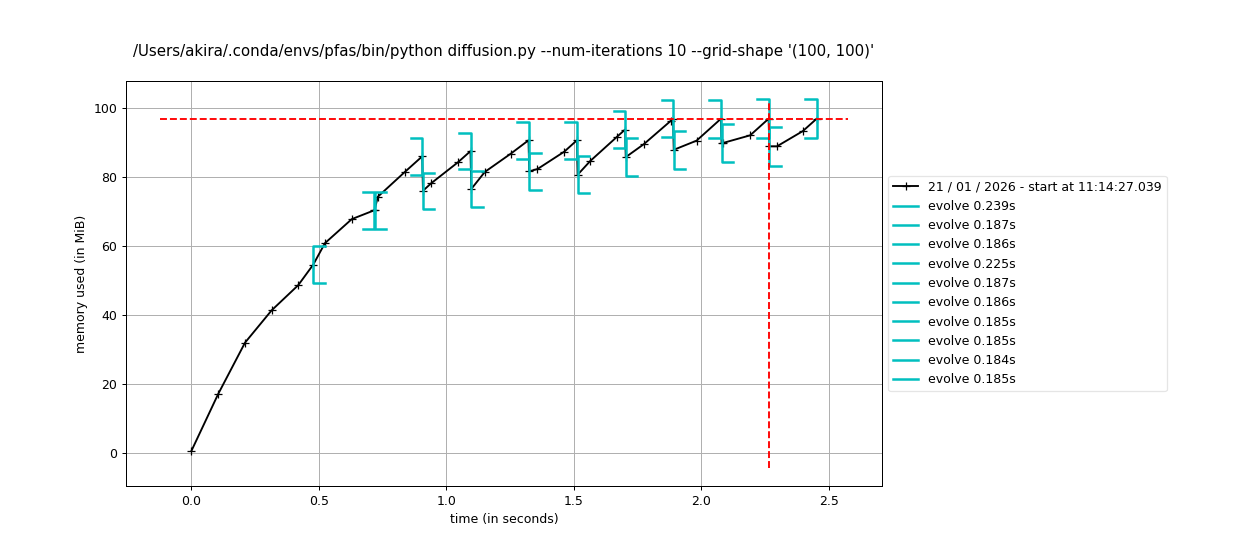